# 트랙 A: HRV 반응 EDA

## 목적
PhysioNet ACTES 데이터셋(38명, RR intervals, power, VO2)을 기반으로 **훈련 부하(ACWR)와 HRV 반응** 간의 관계를 탐색적으로 분석한다.  
실제 데이터가 `data/raw/`에 아직 준비되지 않았을 수 있으므로, **합성(synthetic) 데모 데이터**를 생성하여 전체 EDA 파이프라인의 재현 가능성을 보장한다.

## 데이터셋
- **원본**: PhysioNet ACTES (38명 피험자, 일별 RR intervals, power, VO2)
- **본 노트북**: 합성 데모 데이터 (5명 피험자, 60일)

## EDA 단계
1. **RR/HRV 품질 점검** — 피험자별 ln(rMSSD) 분포 및 결측 비율 확인
2. **부하 지표 산출** — ATL, CTL, ACWR (Rolling Average & EWMA)
3. **Load-HRV 시차(lag) 탐색** — ACWR(t) vs ln_rMSSD(t+1) 산점도
4. **ACWR_RA vs ACWR_EWMA 민감도 비교** — 시계열 오버레이 및 피크 감지 차이

## 통계 모형 (다음 단계)
- `HRV_{t+1} ~ ACWR_t + (1|subject)` (혼합효과 회귀, T-005에서 수행)

In [1]:
# === 환경 설정 및 라이브러리 임포트 ===
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

# 한글 깨짐 방지용 폰트 설정
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# 프로젝트 지표 모듈 임포트
from src.metrics.acwr import (
    atl_rolling, atl_ewma,
    ctl_rolling, ctl_ewma,
    acwr_rolling, acwr_ewma,
)
from src.metrics.hrv_features import rmssd, ln_rmssd, sdnn

# 재현성을 위한 시드 고정
np.random.seed(42)

# 플롯 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('환경 설정 완료.')

환경 설정 완료.


## 합성 데모 데이터 생성

PhysioNet ACTES 데이터셋의 구조를 모사하는 합성 데이터를 생성한다.

### 생성 규칙
- **피험자**: 5명 (`S01` ~ `S05`)
- **기간**: 60일 (일별 데이터)
- **일별 부하(sRPE)**:
  - 평균 400 AU, 표준편차 150
  - 주말(토/일)은 0.5배로 감소 (휴식 패턴 반영)
- **일별 rMSSD**:
  - 부하와 **역상관** 관계 (부하가 높으면 rMSSD 감소)
  - **1일 시차** 적용 (전날 부하가 오늘 HRV에 영향)
  - **개인 랜덤 절편** (피험자별 기저 HRV 수준 차이)
  - 가우시안 노이즈 추가
- **결측**: 피험자당 약 5% 랜덤 결측 삽입

In [2]:
# === 합성 데모 데이터 생성 ===

N_SUBJECTS = 5
N_DAYS = 60
LOAD_MEAN = 400   # AU
LOAD_STD = 150
MISSING_RATE = 0.05  # 5% 결측

# 피험자별 랜덤 절편 (기저 rMSSD 수준)
subject_intercepts = {
    'S01': 45.0,
    'S02': 55.0,
    'S03': 38.0,
    'S04': 50.0,
    'S05': 42.0,
}

rows = []
start_date = pd.Timestamp('2024-01-01')

for subj_id, intercept in subject_intercepts.items():
    dates = pd.date_range(start=start_date, periods=N_DAYS, freq='D')
    
    # --- 일별 부하 생성 ---
    daily_load = np.random.normal(LOAD_MEAN, LOAD_STD, N_DAYS)
    daily_load = np.clip(daily_load, 50, 900)  # 현실적 범위 클리핑
    
    # 주말 휴식 패턴 (토=5, 일=6)
    for i, d in enumerate(dates):
        if d.dayofweek >= 5:  # 토, 일
            daily_load[i] *= 0.5
    
    # 40~45일 사이에 부하 급등(spike) 삽입 (민감도 비교용)
    spike_days = range(40, 46)
    for i in spike_days:
        daily_load[i] = np.random.uniform(700, 900)
    
    # --- 일별 rMSSD 생성 (부하와 역상관, 1일 시차) ---
    rmssd_values = np.zeros(N_DAYS)
    for i in range(N_DAYS):
        if i == 0:
            # 첫날은 기저 수준에서 시작
            prev_load = LOAD_MEAN
        else:
            prev_load = daily_load[i - 1]  # 1일 시차
        
        # rMSSD = 절편 - 0.03 * 전날부하 + 노이즈
        noise = np.random.normal(0, 5)
        rmssd_values[i] = intercept - 0.03 * prev_load + noise
        rmssd_values[i] = max(rmssd_values[i], 10)  # 최소값 보장
    
    # --- 결측 삽입 ---
    missing_mask = np.random.random(N_DAYS) < MISSING_RATE
    rmssd_with_missing = rmssd_values.copy()
    rmssd_with_missing[missing_mask] = np.nan
    
    # --- DataFrame 행 추가 ---
    for i in range(N_DAYS):
        ln_val = np.log(rmssd_with_missing[i]) if not np.isnan(rmssd_with_missing[i]) else np.nan
        rows.append({
            'subject_id': subj_id,
            'day': i + 1,
            'date': dates[i],
            'daily_load': round(daily_load[i], 1),
            'rmssd_value': round(rmssd_with_missing[i], 2) if not np.isnan(rmssd_with_missing[i]) else np.nan,
            'ln_rmssd': round(ln_val, 4) if not np.isnan(ln_val) else np.nan,
        })

df = pd.DataFrame(rows)

print(f'합성 데이터 생성 완료: {df.shape[0]}행, {df["subject_id"].nunique()}명 피험자, {N_DAYS}일')
print(f'결측 비율: {df["rmssd_value"].isna().mean():.1%}')
print()
df.head(10)

합성 데이터 생성 완료: 300행, 5명 피험자, 60일
결측 비율: 5.3%



,subject_id,day,date,daily_load,rmssd_value,ln_rmssd
0,S01,1,2024-01-01,474.5,32.64,3.4855
1,S01,2,2024-01-02,379.3,35.78,3.5775
2,S01,3,2024-01-03,497.2,35.43,3.5676
3,S01,4,2024-01-04,628.5,26.86,3.2906
4,S01,5,2024-01-05,364.9,NaN,NaN
5,S01,6,2024-01-06,182.4,41.74,3.7316
6,S01,7,2024-01-07,318.4,39.35,3.6724
7,S01,8,2024-01-08,515.1,NaN,NaN
8,S01,9,2024-01-09,329.6,16.45,2.8002
9,S01,10,2024-01-10,481.4,39.22,3.6692


## 1단계 -- RR/HRV 품질 점검

각 피험자별 **ln(rMSSD) 분포**와 **결측 비율**을 확인하여 데이터 품질을 점검한다.

- Boxplot으로 피험자 간 분포 차이 및 이상치 확인
- 결측 비율이 20%를 초과하는 피험자는 분석에서 제외 고려

C:\Users\lynn2\AppData\Local\Temp\ipykernel_1000\982730598.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(box_data, labels=subjects, patch_artist=True,


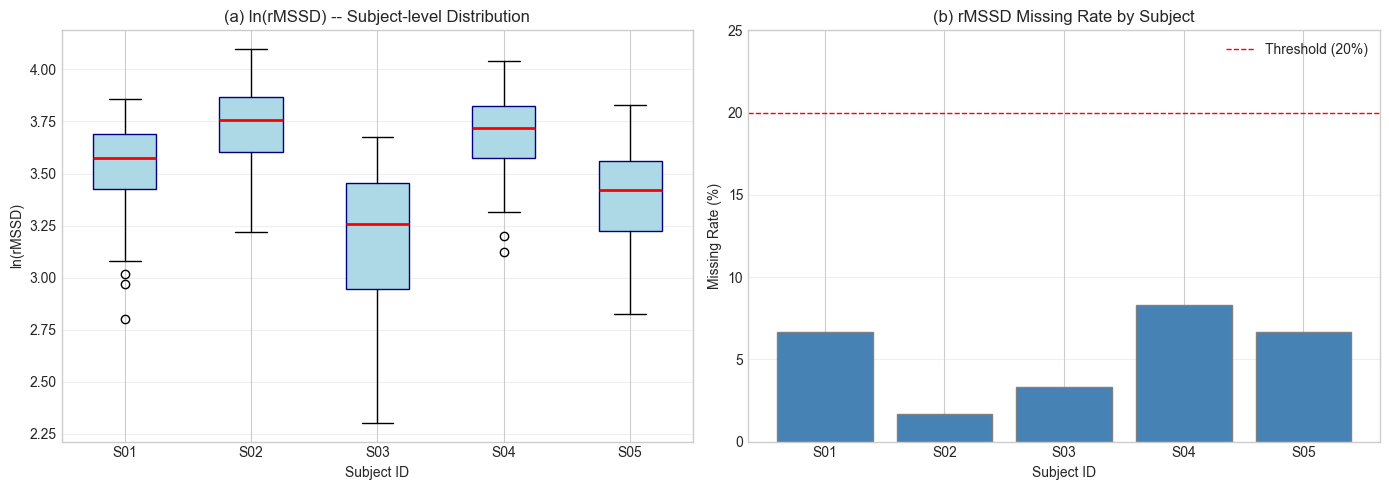

=== HRV Quality Summary ===


,subject_id,n_total,n_valid,n_missing,missing_pct,ln_rmssd_mean,ln_rmssd_std
0,S01,60,56,4,6.7%,3.527,0.224
1,S02,60,59,1,1.7%,3.732,0.200
2,S03,60,58,2,3.3%,3.193,0.363
3,S04,60,55,5,8.3%,3.682,0.196
4,S05,60,56,4,6.7%,3.397,0.242


In [3]:
# === 1단계: HRV 분포 시각화 ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- (a) 피험자별 ln(rMSSD) Boxplot ---
subjects = sorted(df['subject_id'].unique())
box_data = [df.loc[df['subject_id'] == s, 'ln_rmssd'].dropna().values for s in subjects]

bp = axes[0].boxplot(box_data, labels=subjects, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='navy'),
                     medianprops=dict(color='red', linewidth=2))
axes[0].set_xlabel('Subject ID')
axes[0].set_ylabel('ln(rMSSD)')
axes[0].set_title('(a) ln(rMSSD) -- Subject-level Distribution')
axes[0].grid(axis='y', alpha=0.3)

# --- (b) 결측 비율 막대 그래프 ---
missing_table = df.groupby('subject_id')['rmssd_value'].apply(
    lambda x: x.isna().mean() * 100
).reset_index()
missing_table.columns = ['subject_id', 'missing_pct']

colors = ['salmon' if v > 20 else 'steelblue' for v in missing_table['missing_pct']]
axes[1].bar(missing_table['subject_id'], missing_table['missing_pct'], color=colors, edgecolor='gray')
axes[1].axhline(y=20, color='red', linestyle='--', linewidth=1, label='Threshold (20%)')
axes[1].set_xlabel('Subject ID')
axes[1].set_ylabel('Missing Rate (%)')
axes[1].set_title('(b) rMSSD Missing Rate by Subject')
axes[1].legend()
axes[1].set_ylim(0, max(missing_table['missing_pct'].max() * 1.5, 25))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- 결측 비율 표 ---
summary = df.groupby('subject_id').agg(
    n_total=('rmssd_value', 'size'),
    n_valid=('rmssd_value', 'count'),
    n_missing=('rmssd_value', lambda x: x.isna().sum()),
    missing_pct=('rmssd_value', lambda x: f"{x.isna().mean()*100:.1f}%"),
    ln_rmssd_mean=('ln_rmssd', lambda x: round(x.mean(), 3)),
    ln_rmssd_std=('ln_rmssd', lambda x: round(x.std(), 3)),
).reset_index()

print('=== HRV Quality Summary ===')
summary

## 2단계 -- 부하 지표 산출

각 피험자별로 `src/metrics/acwr.py` 모듈을 사용하여 다음 지표를 산출한다:

| 지표 | 방식 | 윈도우/스팬 |
|------|------|------------|
| ATL (급성 훈련 부하) | Rolling Average | 7일 |
| ATL (급성 훈련 부하) | EWMA | span=7 |
| CTL (만성 훈련 부하) | Rolling Average | 28일 |
| CTL (만성 훈련 부하) | EWMA | span=28 |
| ACWR | Rolling Average | ATL_7 / CTL_28 |
| ACWR | EWMA | ATL_ewma_7 / CTL_ewma_28 |

부하 지표 산출 완료: 300행, 컬럼 = ['subject_id', 'day', 'date', 'daily_load', 'rmssd_value', 'ln_rmssd', 'atl_rolling', 'atl_ewma', 'ctl_rolling', 'ctl_ewma', 'acwr_rolling', 'acwr_ewma']

ACWR Rolling 유효 데이터: 165행
ACWR EWMA 유효 데이터: 195행



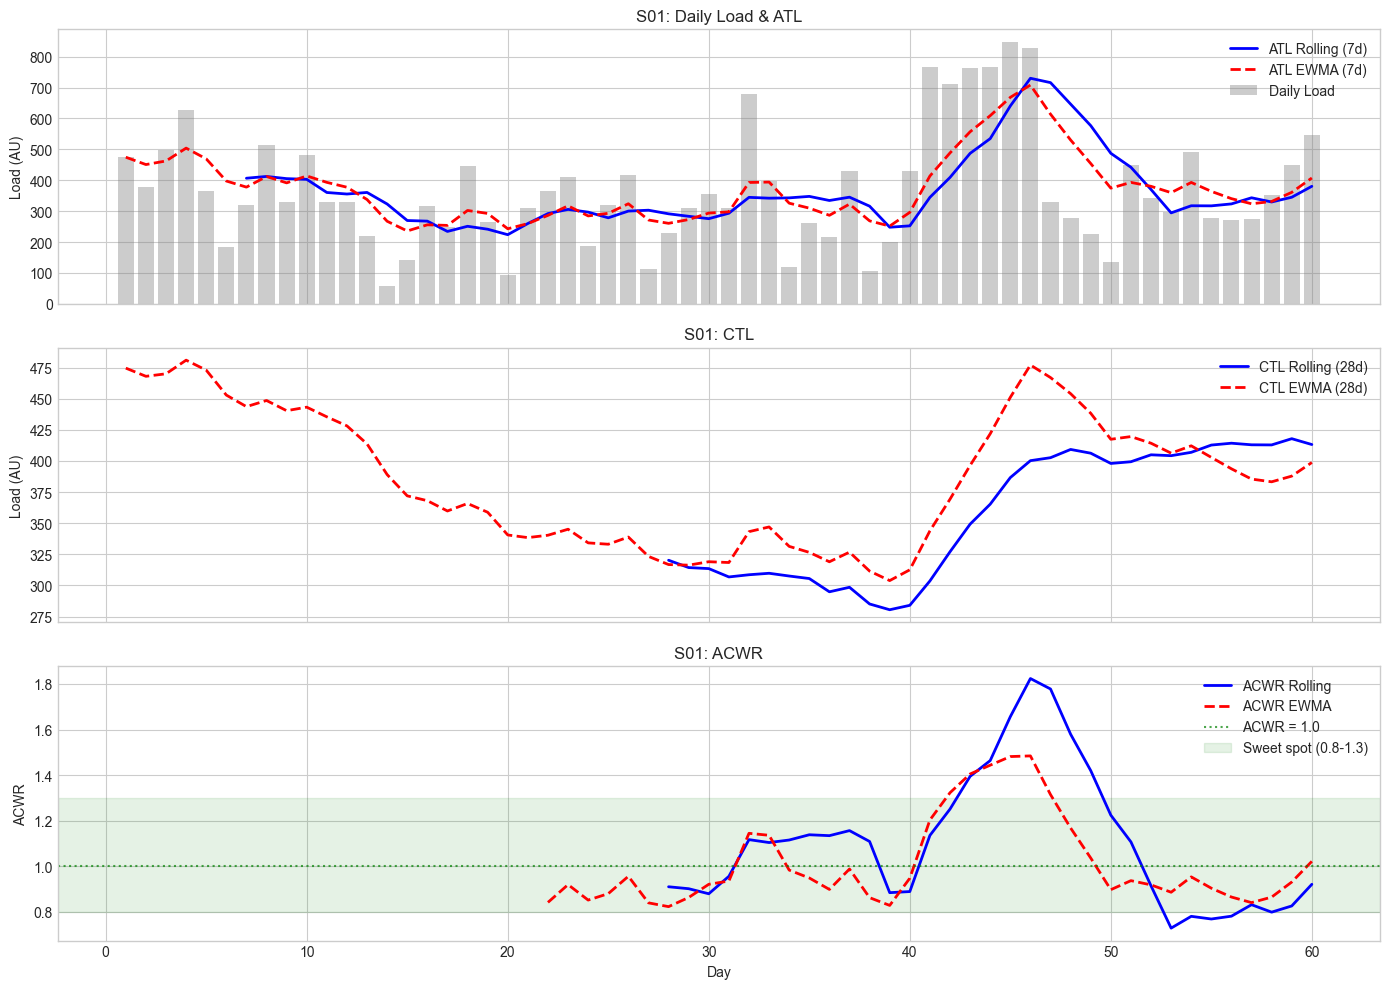

In [4]:
# === 2단계: ATL / CTL / ACWR 산출 ===

result_frames = []

for subj in subjects:
    sub_df = df[df['subject_id'] == subj].copy().sort_values('day').reset_index(drop=True)
    loads = sub_df['daily_load']
    
    # ATL 산출
    sub_df['atl_rolling'] = atl_rolling(loads, window=7).values
    sub_df['atl_ewma'] = atl_ewma(loads, span=7).values
    
    # CTL 산출
    sub_df['ctl_rolling'] = ctl_rolling(loads, window=28).values
    sub_df['ctl_ewma'] = ctl_ewma(loads, span=28).values
    
    # ACWR 산출
    sub_df['acwr_rolling'] = acwr_rolling(loads, atl_window=7, ctl_window=28).values
    sub_df['acwr_ewma'] = acwr_ewma(loads, atl_span=7, ctl_span=28, warmup=21).values
    
    result_frames.append(sub_df)

df_full = pd.concat(result_frames, ignore_index=True)

print(f'부하 지표 산출 완료: {df_full.shape[0]}행, 컬럼 = {list(df_full.columns)}')
print()

# 유효 ACWR 데이터 확인
valid_acwr = df_full.dropna(subset=['acwr_rolling', 'acwr_ewma'])
print(f'ACWR Rolling 유효 데이터: {df_full["acwr_rolling"].notna().sum()}행')
print(f'ACWR EWMA 유효 데이터: {df_full["acwr_ewma"].notna().sum()}행')
print()

# 대표 피험자 시계열 확인
sample_subj = 'S01'
sample = df_full[df_full['subject_id'] == sample_subj].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# (a) 일별 부하 + ATL
axes[0].bar(sample['day'], sample['daily_load'], alpha=0.4, color='gray', label='Daily Load')
axes[0].plot(sample['day'], sample['atl_rolling'], 'b-', linewidth=2, label='ATL Rolling (7d)')
axes[0].plot(sample['day'], sample['atl_ewma'], 'r--', linewidth=2, label='ATL EWMA (7d)')
axes[0].set_ylabel('Load (AU)')
axes[0].set_title(f'{sample_subj}: Daily Load & ATL')
axes[0].legend(loc='upper right')

# (b) CTL
axes[1].plot(sample['day'], sample['ctl_rolling'], 'b-', linewidth=2, label='CTL Rolling (28d)')
axes[1].plot(sample['day'], sample['ctl_ewma'], 'r--', linewidth=2, label='CTL EWMA (28d)')
axes[1].set_ylabel('Load (AU)')
axes[1].set_title(f'{sample_subj}: CTL')
axes[1].legend(loc='upper right')

# (c) ACWR
axes[2].plot(sample['day'], sample['acwr_rolling'], 'b-', linewidth=2, label='ACWR Rolling')
axes[2].plot(sample['day'], sample['acwr_ewma'], 'r--', linewidth=2, label='ACWR EWMA')
axes[2].axhline(y=1.0, color='green', linestyle=':', alpha=0.7, label='ACWR = 1.0')
axes[2].axhspan(0.8, 1.3, alpha=0.1, color='green', label='Sweet spot (0.8-1.3)')
axes[2].set_ylabel('ACWR')
axes[2].set_xlabel('Day')
axes[2].set_title(f'{sample_subj}: ACWR')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 3단계 -- Load-HRV 시차(lag) 탐색

**핵심 가설**: 훈련 부하(ACWR)가 높은 날의 **다음 날** HRV(ln_rMSSD)가 감소한다.

- ACWR(t) vs ln_rMSSD(t+1) 산점도 (lag = 1일)
- 피험자별 색상 구분
- 전체 Pearson 상관계수 및 p-value 표시

이 분석은 이후 혼합효과 모형 `HRV_{t+1} ~ ACWR_t + (1|subject)`의 기초가 된다.

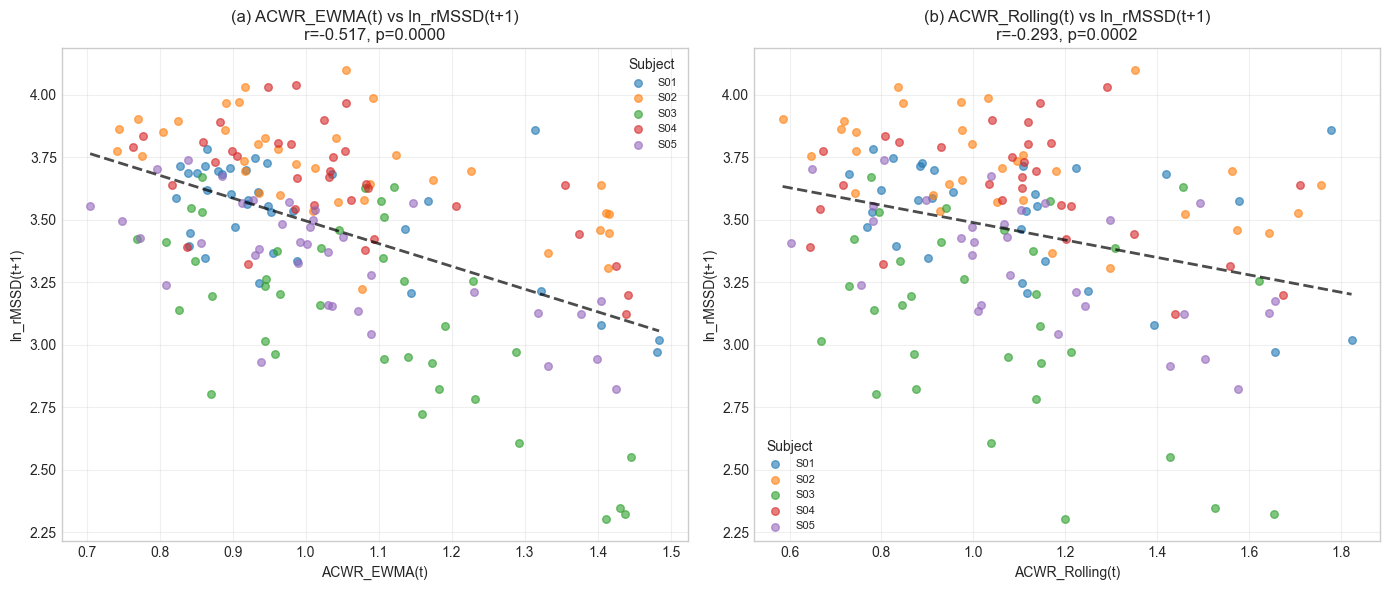

=== ACWR(t) vs ln_rMSSD(t+1): Pearson Correlation by Subject ===


,subject_id,n_ewma,r_ewma,p_ewma,n_rolling,r_rolling,p_rolling
0,S01,36,-0.635,0.0000,30,-0.402,0.0278
1,S02,37,-0.633,0.0000,32,-0.480,0.0055
2,S03,38,-0.692,0.0000,32,-0.365,0.0401
3,S04,34,-0.590,0.0002,29,-0.287,0.1307
4,S05,36,-0.690,0.0000,30,-0.606,0.0004


In [5]:
# === 3단계: ACWR(t) vs ln_rMSSD(t+1) Lag Plot ===

# 시차 변수 생성: 각 피험자별로 ln_rmssd를 1일 앞으로 이동 (t+1)
lag_frames = []
for subj in subjects:
    sub = df_full[df_full['subject_id'] == subj].copy().sort_values('day')
    sub['ln_rmssd_next'] = sub['ln_rmssd'].shift(-1)  # t+1 시점의 ln_rmssd
    lag_frames.append(sub)

df_lag = pd.concat(lag_frames, ignore_index=True)

# ACWR EWMA 기준으로 분석 (Rolling도 유사)
df_lag_valid = df_lag.dropna(subset=['acwr_ewma', 'ln_rmssd_next'])

# --- 산점도 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_map = {'S01': '#1f77b4', 'S02': '#ff7f0e', 'S03': '#2ca02c', 'S04': '#d62728', 'S05': '#9467bd'}

# (a) ACWR_EWMA(t) vs ln_rMSSD(t+1)
for subj in subjects:
    mask = df_lag_valid['subject_id'] == subj
    axes[0].scatter(
        df_lag_valid.loc[mask, 'acwr_ewma'],
        df_lag_valid.loc[mask, 'ln_rmssd_next'],
        alpha=0.6, s=30, label=subj, color=colors_map[subj]
    )

# 전체 회귀선
x_all = df_lag_valid['acwr_ewma'].values
y_all = df_lag_valid['ln_rmssd_next'].values
r_ewma, p_ewma = stats.pearsonr(x_all, y_all)
z = np.polyfit(x_all, y_all, 1)
x_line = np.linspace(x_all.min(), x_all.max(), 100)
axes[0].plot(x_line, np.polyval(z, x_line), 'k--', linewidth=2, alpha=0.7)
axes[0].set_xlabel('ACWR_EWMA(t)')
axes[0].set_ylabel('ln_rMSSD(t+1)')
axes[0].set_title(f'(a) ACWR_EWMA(t) vs ln_rMSSD(t+1)\nr={r_ewma:.3f}, p={p_ewma:.4f}')
axes[0].legend(title='Subject', fontsize=8)
axes[0].grid(alpha=0.3)

# (b) ACWR_Rolling(t) vs ln_rMSSD(t+1)
df_lag_valid_ra = df_lag.dropna(subset=['acwr_rolling', 'ln_rmssd_next'])

for subj in subjects:
    mask = df_lag_valid_ra['subject_id'] == subj
    axes[1].scatter(
        df_lag_valid_ra.loc[mask, 'acwr_rolling'],
        df_lag_valid_ra.loc[mask, 'ln_rmssd_next'],
        alpha=0.6, s=30, label=subj, color=colors_map[subj]
    )

x_ra = df_lag_valid_ra['acwr_rolling'].values
y_ra = df_lag_valid_ra['ln_rmssd_next'].values
r_ra, p_ra = stats.pearsonr(x_ra, y_ra)
z_ra = np.polyfit(x_ra, y_ra, 1)
x_line_ra = np.linspace(x_ra.min(), x_ra.max(), 100)
axes[1].plot(x_line_ra, np.polyval(z_ra, x_line_ra), 'k--', linewidth=2, alpha=0.7)
axes[1].set_xlabel('ACWR_Rolling(t)')
axes[1].set_ylabel('ln_rMSSD(t+1)')
axes[1].set_title(f'(b) ACWR_Rolling(t) vs ln_rMSSD(t+1)\nr={r_ra:.3f}, p={p_ra:.4f}')
axes[1].legend(title='Subject', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- 피험자별 상관계수 표 ---
corr_rows = []
for subj in subjects:
    sub_ewma = df_lag_valid[df_lag_valid['subject_id'] == subj]
    sub_ra = df_lag_valid_ra[df_lag_valid_ra['subject_id'] == subj]
    
    if len(sub_ewma) > 2:
        r_e, p_e = stats.pearsonr(sub_ewma['acwr_ewma'], sub_ewma['ln_rmssd_next'])
    else:
        r_e, p_e = np.nan, np.nan
    if len(sub_ra) > 2:
        r_r, p_r = stats.pearsonr(sub_ra['acwr_rolling'], sub_ra['ln_rmssd_next'])
    else:
        r_r, p_r = np.nan, np.nan
    
    corr_rows.append({
        'subject_id': subj,
        'n_ewma': len(sub_ewma),
        'r_ewma': round(r_e, 3),
        'p_ewma': round(p_e, 4),
        'n_rolling': len(sub_ra),
        'r_rolling': round(r_r, 3),
        'p_rolling': round(p_r, 4),
    })

df_corr = pd.DataFrame(corr_rows)
print('=== ACWR(t) vs ln_rMSSD(t+1): Pearson Correlation by Subject ===')
df_corr

## 4단계 -- ACWR_RA vs ACWR_EWMA 민감도 비교

Rolling Average(RA)와 EWMA 방식의 ACWR 산출 결과를 비교한다.

### 분석 포인트
- **시계열 오버레이**: 동일 피험자의 ACWR_RA vs ACWR_EWMA 시계열 비교
- **부하 급등(spike) 구간 하이라이트**: 40~45일 사이에 삽입된 부하 급등 구간에서 두 방식의 반응 차이 관찰
- **피크 감지 차이**: RA는 과거 데이터의 급격한 유입/이탈에 민감하고, EWMA는 더 평활된 반응을 보인다

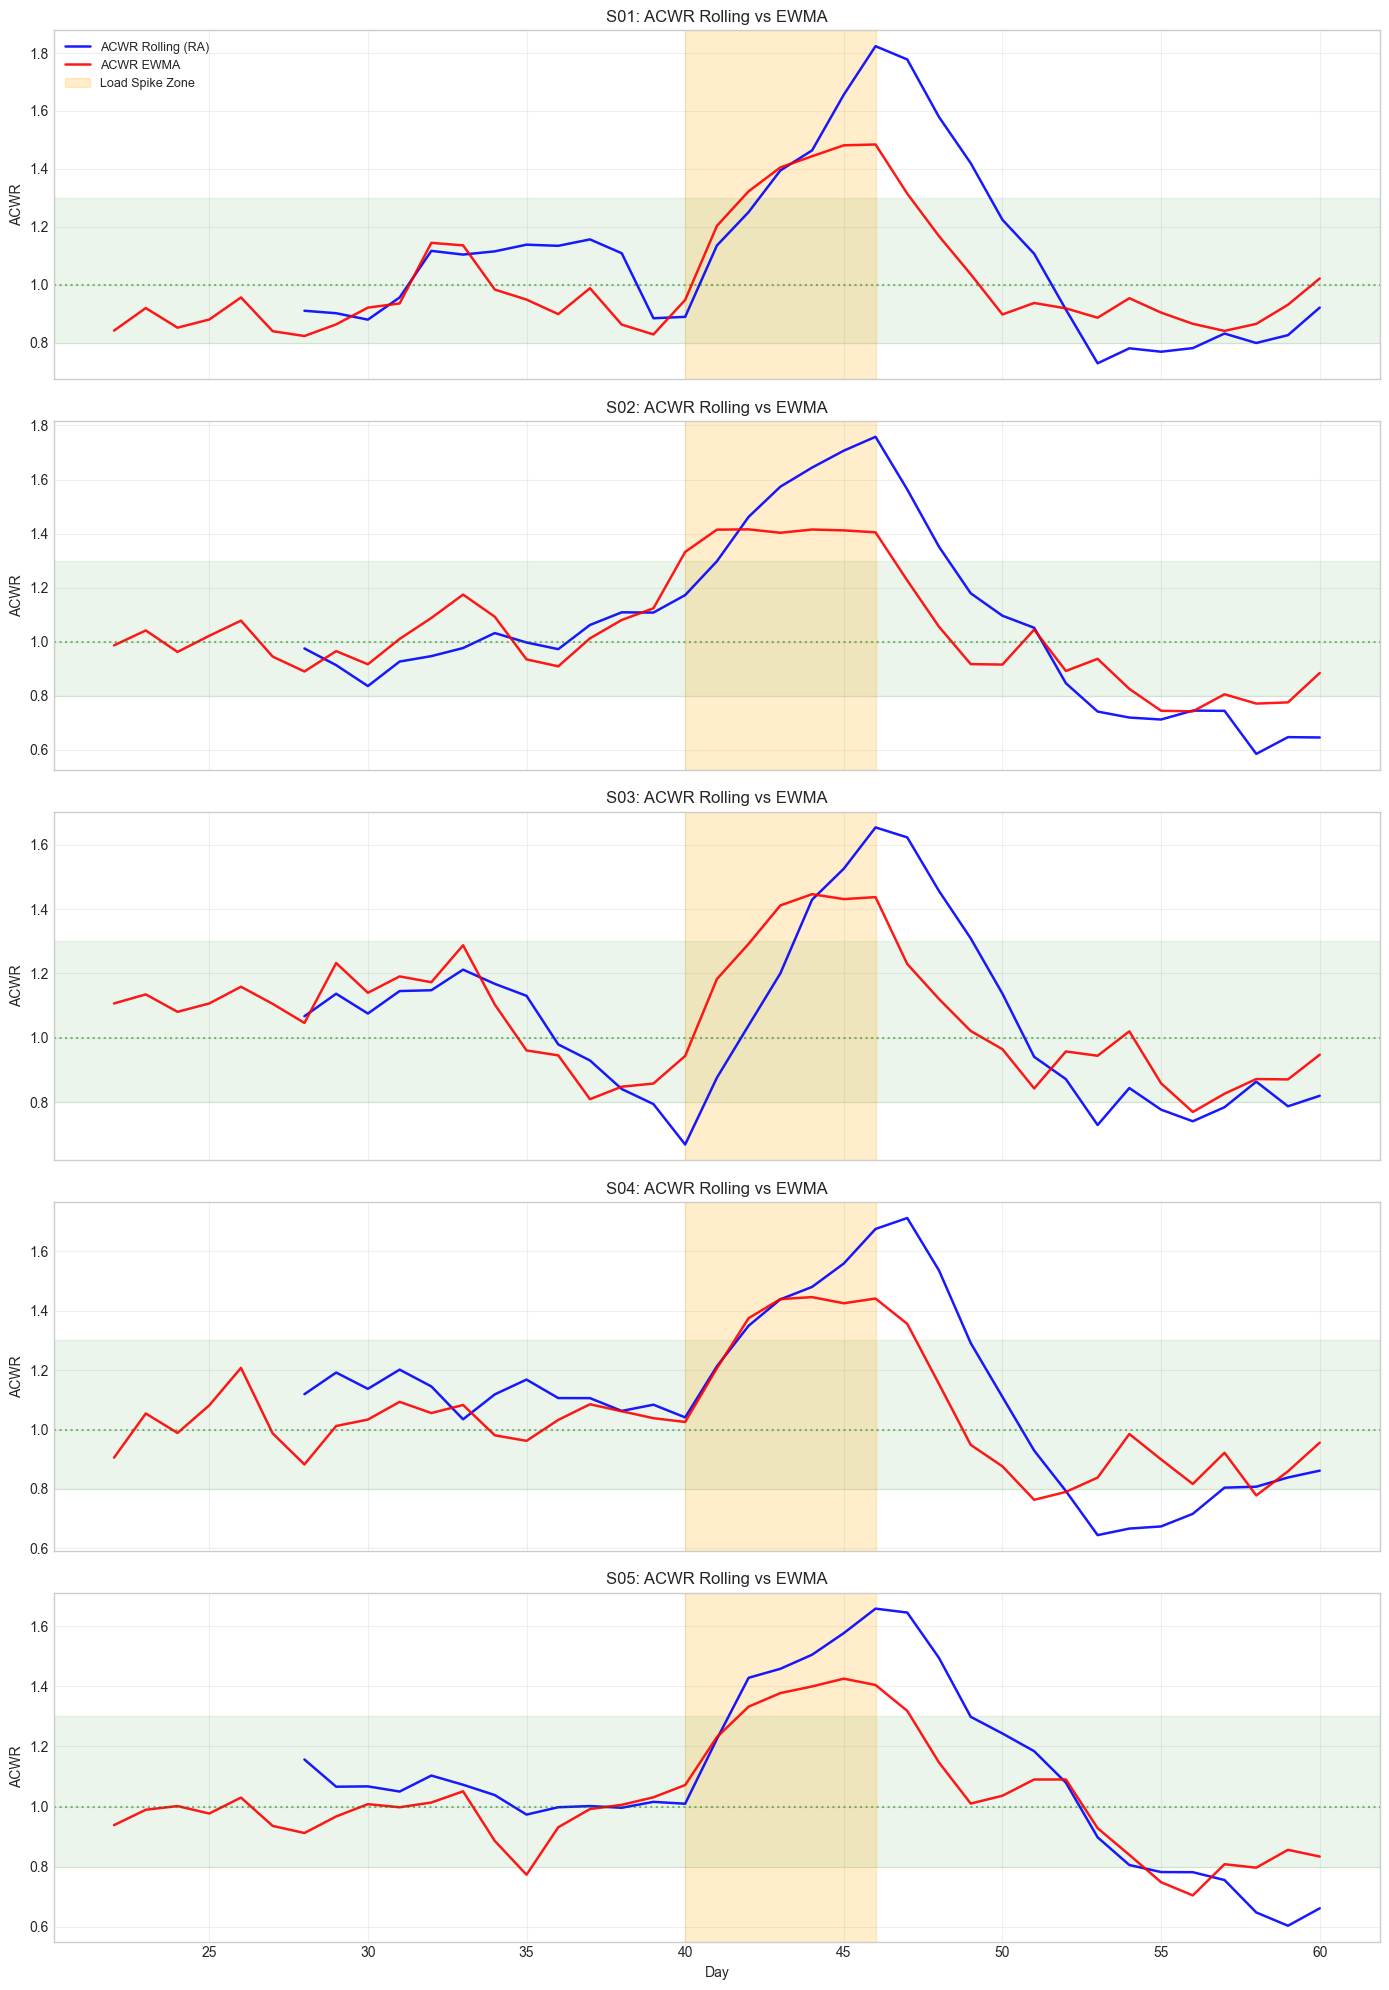

=== Spike Zone (Day 40-46) ACWR Peak Comparison ===

RA는 윈도우 경계 효과로 더 급격한 피크를 보이는 경향이 있다.
EWMA는 지수 가중으로 인해 더 완만한 피크를 보인다.



,subject_id,RA_peak,RA_peak_day,EWMA_peak,EWMA_peak_day,peak_diff
0,S01,1.824,46,1.484,46,0.340
1,S02,1.758,46,1.416,42,0.343
2,S03,1.654,46,1.446,44,0.208
3,S04,1.712,47,1.446,44,0.266
4,S05,1.658,46,1.425,45,0.233


In [6]:
# === 4단계: ACWR_RA vs ACWR_EWMA 민감도 비교 ===

fig, axes = plt.subplots(N_SUBJECTS, 1, figsize=(14, 4 * N_SUBJECTS), sharex=True)

spike_start, spike_end = 40, 46  # 부하 급등 구간 (day 기준)

for idx, subj in enumerate(subjects):
    sub = df_full[df_full['subject_id'] == subj].copy().sort_values('day')
    ax = axes[idx]
    
    # ACWR 시계열
    ax.plot(sub['day'], sub['acwr_rolling'], 'b-', linewidth=1.8, label='ACWR Rolling (RA)', alpha=0.9)
    ax.plot(sub['day'], sub['acwr_ewma'], 'r-', linewidth=1.8, label='ACWR EWMA', alpha=0.9)
    
    # Sweet spot 영역
    ax.axhspan(0.8, 1.3, alpha=0.08, color='green')
    ax.axhline(y=1.0, color='green', linestyle=':', alpha=0.5)
    
    # 부하 급등 구간 하이라이트
    ax.axvspan(spike_start, spike_end, alpha=0.2, color='orange', label='Load Spike Zone')
    
    ax.set_ylabel('ACWR')
    ax.set_title(f'{subj}: ACWR Rolling vs EWMA')
    if idx == 0:
        ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Day')
plt.tight_layout()
plt.show()

# --- 피크 감지 차이 비교 ---
print('=== Spike Zone (Day 40-46) ACWR Peak Comparison ===')
print()

peak_rows = []
for subj in subjects:
    sub = df_full[df_full['subject_id'] == subj].copy()
    spike_zone = sub[(sub['day'] >= spike_start) & (sub['day'] <= spike_end + 5)]  # +5일까지 관찰
    
    ra_peak = spike_zone['acwr_rolling'].max()
    ra_peak_day = spike_zone.loc[spike_zone['acwr_rolling'].idxmax(), 'day'] if not spike_zone['acwr_rolling'].isna().all() else np.nan
    ewma_peak = spike_zone['acwr_ewma'].max()
    ewma_peak_day = spike_zone.loc[spike_zone['acwr_ewma'].idxmax(), 'day'] if not spike_zone['acwr_ewma'].isna().all() else np.nan
    
    peak_rows.append({
        'subject_id': subj,
        'RA_peak': round(ra_peak, 3) if not np.isnan(ra_peak) else np.nan,
        'RA_peak_day': int(ra_peak_day) if not np.isnan(ra_peak_day) else np.nan,
        'EWMA_peak': round(ewma_peak, 3) if not np.isnan(ewma_peak) else np.nan,
        'EWMA_peak_day': int(ewma_peak_day) if not np.isnan(ewma_peak_day) else np.nan,
        'peak_diff': round(abs(ra_peak - ewma_peak), 3) if not (np.isnan(ra_peak) or np.isnan(ewma_peak)) else np.nan,
    })

df_peaks = pd.DataFrame(peak_rows)
print('RA는 윈도우 경계 효과로 더 급격한 피크를 보이는 경향이 있다.')
print('EWMA는 지수 가중으로 인해 더 완만한 피크를 보인다.')
print()
df_peaks

## 요약 및 다음 단계

### 주요 EDA 관찰

1. **HRV 품질**: 합성 데이터에서 결측 비율은 약 5% 수준으로, 분석에 충분한 데이터 품질을 보인다. 피험자별 ln(rMSSD) 분포는 개인차(랜덤 절편)를 명확히 반영한다.

2. **부하-HRV 시차 관계**: ACWR(t)와 ln_rMSSD(t+1) 간에 **음의 상관관계**가 관찰되며, 이는 "높은 부하 -> 다음 날 HRV 감소"라는 가설을 지지한다. 혼합효과 모형을 통해 개인차를 통제한 정밀한 추정이 필요하다.

3. **ACWR 산출 방식 차이**:
   - **Rolling Average(RA)**: 부하 급등 시 윈도우 경계 효과로 인해 더 급격한 피크와 강하를 보인다.
   - **EWMA**: 지수 가중으로 인해 더 평활된 반응을 보이며, 피크 크기가 상대적으로 작다.
   - 부하 급등 구간(Day 40-46)에서 두 방식의 차이가 가장 두드러진다.

4. **개인차**: 피험자별 기저 HRV 수준이 크게 다르므로, 랜덤 절편을 포함한 혼합효과 모형이 적절하다.

### 다음 단계: 통계 분석 (T-005)

- **혼합효과 회귀**: `HRV_{t+1} ~ ACWR_t + (1|subject)` 모형 적합
- ACWR_RA와 ACWR_EWMA 각각에 대해 모형 비교
- 잔차 진단 및 모형 가정 검증
- PhysioNet ACTES 실제 데이터에 동일 파이프라인 적용